### Check out augmentations on HPA

In [1]:
from dataset import HPADatasetFourChannelsImages
from utils import train_valid_split_multilabel

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

import torch
import torchvision.transforms.v2 as transforms
from torchvision.utils import make_grid

In [27]:
def train_transformations() -> transforms.Compose:
    '''
    Returns a composition of transformations to be applied to the training images.
    Returns:
        transforms.Compose
            The composition of transformations.
    '''
    return transforms.Compose([
        # transforms.ToImage(), # Transformar de tensor para imagem
        # transforms.Lambda(lambda x: x.to(torch.float32)),  # Ensure float32 dtype
        # transforms.ElasticTransform(alpha=50.0, sigma=5.0),
        transforms.ToDtype(torch.float32, scale=True),
    ])


def valid_transformations() -> transforms.Compose:
    '''
    Returns a composition of transformations to be applied to the validation images.
    Returns:
        transforms.Compose
            The composition of transformations.
    '''
    return transforms.Compose([
        # transforms.Lambda(lambda x: x.to(torch.float32)),  # Ensure float32 dtype
        # transforms.ToImage(), # Transformar de tensor para imagem
        transforms.ToDtype(torch.float32, scale=True),
    ])

In [ ]:
def train_transformations() -> transforms.Compose:
    '''
    Returns a composition of transformations to be applied to the training images.
    Returns:
        transforms.Compose
            The composition of transformations.
    '''
    return transforms.Compose([
        transforms.ToImage(), # Transformar de tensor para imagem
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Normalize(mean=[0.0807, 0.0804, 0.0538, 0.0522], std=[0.1233, 0.1273, 0.1422, 0.0818])
    ])


def valid_transformations() -> transforms.Compose:
    '''
    Returns a composition of transformations to be applied to the validation images.
    Returns:
        transforms.Compose
            The composition of transformations.
    '''
    return transforms.Compose([
        transforms.ToImage(), # Transformar de tensor para imagem
        transforms.ToDtype(torch.float32, scale=True),
        transforms.Normalize(mean=[0.0807, 0.0804, 0.0538, 0.0522], std=[0.1233, 0.1273, 0.1422, 0.0818])
    ])

In [28]:
# /mnt/ssd/hpa-single-cell-image-classification

dataset_path = "/mnt/ssd/hpa-single-cell-image-classification/join_resized_train"
labels_path = "/mnt/ssd/hpa-single-cell-image-classification/train.csv"

train, valid = train_valid_split_multilabel(
        hpa_dataset_class=HPADatasetFourChannelsImages,
        dataset_dir=dataset_path,
        labels_csv=labels_path,
        train_transform=train_transformations(),
        valid_transform=valid_transformations(),
        test_size=0.10,
    )

Total samples: 21806

Sorted label counts: (train)
Nucleoplasm: 7955
Cytosol: 5116
Plasma membrane: 2790
Nucleoli: 2174
Mitochondria: 1808
Golgi apparatus: 1641
Nuclear bodies: 1620
Centrosome: 1576
Nuclear speckles: 1285
Nucleoli fibrillar center: 1136
Nuclear membrane: 983
Actin filaments: 907
Intermediate filaments: 873
Microtubules: 726
Endoplasmic reticulum: 695
Vesicles and punctate cytosolic patterns: 532
Aggresome: 234
Mitotic spindle: 68
Negative: 32

Sorted label counts: (valid)
Nucleoplasm: 842
Cytosol: 569
Plasma membrane: 321
Nucleoli: 277
Golgi apparatus: 205
Mitochondria: 205
Nuclear bodies: 172
Centrosome: 158
Nuclear speckles: 140
Nucleoli fibrillar center: 126
Nuclear membrane: 112
Microtubules: 92
Intermediate filaments: 91
Actin filaments: 91
Endoplasmic reticulum: 80
Vesicles and punctate cytosolic patterns: 61
Aggresome: 18
Mitotic spindle: 10
Negative: 2


In [29]:
# Show some images
print("Train dataset")
for i in range(5):
    image, target = train[i]
    print(image)
    print(target)
    plt.show()

Train dataset
tensor([[[0.5333, 0.4039, 0.4392,  ..., 0.0235, 0.0588, 0.0980],
         [0.4196, 0.2706, 0.2549,  ..., 0.0353, 0.0510, 0.1255],
         [0.3137, 0.2039, 0.2235,  ..., 0.1020, 0.0510, 0.0941],
         ...,
         [0.0471, 0.0392, 0.0275,  ..., 0.0000, 0.0000, 0.0039],
         [0.0431, 0.0510, 0.0431,  ..., 0.0000, 0.0000, 0.0039],
         [0.0353, 0.0353, 0.0510,  ..., 0.0000, 0.0000, 0.0039]],

        [[0.2314, 0.1020, 0.1176,  ..., 0.0118, 0.0039, 0.0039],
         [0.1137, 0.0627, 0.1294,  ..., 0.0000, 0.0000, 0.0078],
         [0.0667, 0.0784, 0.2549,  ..., 0.0000, 0.0000, 0.0118],
         ...,
         [0.0000, 0.0000, 0.0000,  ..., 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000,  ..., 0.0078, 0.0039, 0.0118],
         [0.0000, 0.0000, 0.0000,  ..., 0.0235, 0.0157, 0.0431]],

        [[0.0039, 0.0039, 0.0118,  ..., 0.0549, 0.0588, 0.0588],
         [0.0039, 0.0078, 0.0235,  ..., 0.0471, 0.0588, 0.0706],
         [0.0078, 0.0118, 0.0235,  ..., 0.06

In [22]:
# Define a function to create a colormap where 0 is black and > 0 is the specified color
def create_colormap(color):
    return LinearSegmentedColormap.from_list('custom_cmap', ['black', color])

In [23]:
def plot_image_with_4_channels(dataset, index):
    """
    Plota uma imagem com 4 canais do dataset em subplots.
    
    Args:
        dataset: O dataset que contém as imagens.
        index: O índice da amostra da qual a imagem deve ser extraída.
    """
    # Obtém a imagem com 4 canais
    image = dataset.__getitem__(index)[0]
    
    # Verifica se a imagem tem 4 canais
    assert image.shape[0] == 4, "A imagem deve ter 4 canais."
    
    # Configura a figura com 4 subplots
    fig, axs = plt.subplots(1, 4, figsize=(15, 5))
    
    # Nomes dos canais para os títulos
    channel_names = ['blue', 'red', 'orange', 'green']
    text_names = ['Nucleus', 'Microtubules', 'Endoplasmic Reticula', 'Protein of Interest']
    
    for i in range(4):
        # Plota cada canal
        axs[i].imshow(image[i].numpy(), cmap=create_colormap(channel_names[i]), vmin=0, vmax=1)
        axs[i].set_title(text_names[i], fontsize=12)
        axs[i].axis('off')  # Remove os eixos
    
    # Ajusta o layout
    plt.tight_layout()
    plt.show()

In [24]:
def plot_image_with_4_channels_overlaid(dataset, index):
    """
    Plota uma imagem com 4 canais do dataset sobreposta em uma única figura,
    garantindo que todas as cores apareçam corretamente.
    
    Args:
        dataset: O dataset que contém as imagens.
        index: O índice da amostra da qual a imagem deve ser extraída.
    """
    # Obtém a imagem com 4 canais
    image = dataset.__getitem__(index)[0]
    labels = dataset.__getitem__(index)[1]
    # labels_names = [classes_map[i] for i in range(len(labels)) if labels[i] == 1]
    
    # Verifica se a imagem tem 4 canais
    assert image.shape[0] == 4, "A imagem deve ter 4 canais."
    
    # Nomes dos canais e suas cores
    channel_colors = {
        'blue': (0, 0, 1, 0.3),   # azul com alpha 0.5
        'red': (1, 0, 0, 0.3),    # vermelho com alpha 0.5
        'orange': (1, 0.6, 0, 0.3), # laranja com alpha 0.5
        'green': (0, 1, 0, 0),  # verde com alpha 0.5
    }

    # Cria a figura
    fig, ax = plt.subplots(figsize=(5, 5))
    
    # Inicializa uma matriz RGB vazia com zeros (3 canais de cores)
    combined_image = np.zeros((image.shape[1], image.shape[2], 3), dtype=np.float32)
    
    # Plota cada canal com a cor correspondente e transparência
    for i, (channel_name, color) in enumerate(channel_colors.items()):
        channel_image = image[i].numpy()
        # Normaliza o canal para garantir que os valores estão entre 0 e 1
        channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
        
        # Adiciona o canal colorido à imagem combinada
        for j in range(3):  # Para cada canal RGB
            combined_image[:, :, j] += channel_image * color[j]
    
    # Garante que os valores da imagem combinada não ultrapassem 1
    combined_image = np.clip(combined_image, 0, 1)
    
    # Mostra a imagem final
    ax.imshow(combined_image)
    ax.axis('off')
    # Coloca os rótulos dessa imagem na legenda
    # plt.title(labels_names, fontsize=12)
    plt.tight_layout()
    plt.show()

In [25]:
import numpy as np
import matplotlib.pyplot as plt

def plot_9_images_with_4_channels_overlaid(dataset, indices):
    """
    Plota uma grade 3x3 de imagens do dataset com 4 canais sobrepostos em uma única figura.
    
    Args:
        dataset: O dataset que contém as imagens.
        indices: Lista de 9 índices das amostras a serem plotadas.
    """
    assert len(indices) == 9, "Forneça exatamente 9 índices para a visualização 3x3."
    
    # Nomes dos canais e suas cores
    channel_colors = {
        'blue': (0, 0, 1, 0.3),   # Azul com alpha
        'red': (1, 0, 0, 0.3),    # Vermelho com alpha
        'orange': (1, 0.6, 0, 0.3), # Laranja com alpha
        'green': (0, 1, 0, 0),  # Verde com alpha
    }

    # Criar a grade 3x3
    fig, axes = plt.subplots(3, 3, figsize=(9, 9))

    for idx, ax in zip(indices, axes.ravel()):
        # Obtém a imagem com 4 canais
        image = dataset.__getitem__(idx)[0]

        # Inicializa uma matriz RGB vazia
        combined_image = np.zeros((image.shape[1], image.shape[2], 3), dtype=np.float32)

        # Adiciona cada canal com sua respectiva cor
        for i, (_, color) in enumerate(channel_colors.items()):
            channel_image = image[i].numpy()
            channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)

            for j in range(3):  # Para cada canal RGB
                combined_image[:, :, j] += channel_image * color[j]

        # Garante que os valores da imagem combinada não ultrapassem 1
        combined_image = np.clip(combined_image, 0, 1)

        # Mostra a imagem
        ax.imshow(combined_image)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

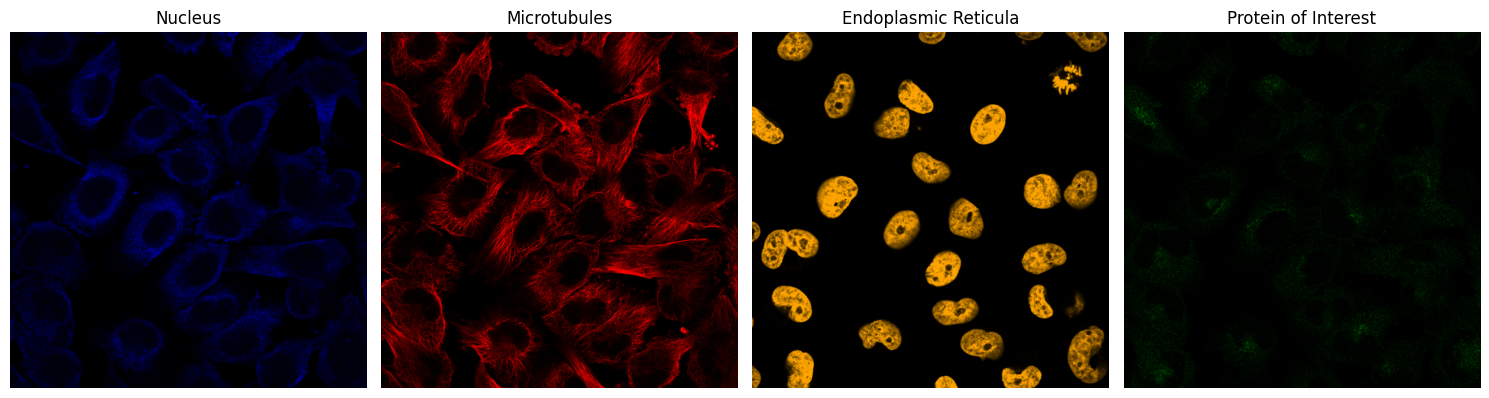

In [26]:
# Exemplo de uso:
plot_image_with_4_channels(train, 15)

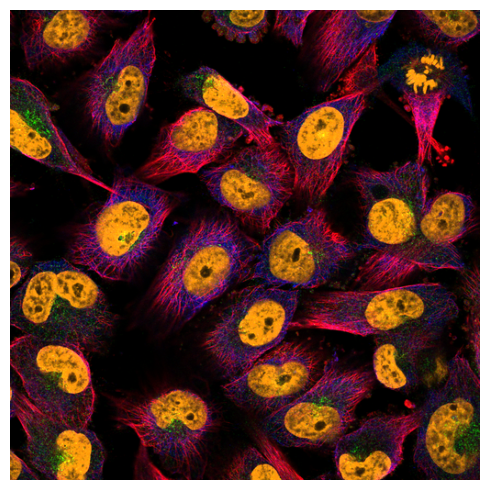

In [12]:
# Exemplo de uso:
plot_image_with_4_channels_overlaid(train, 15)

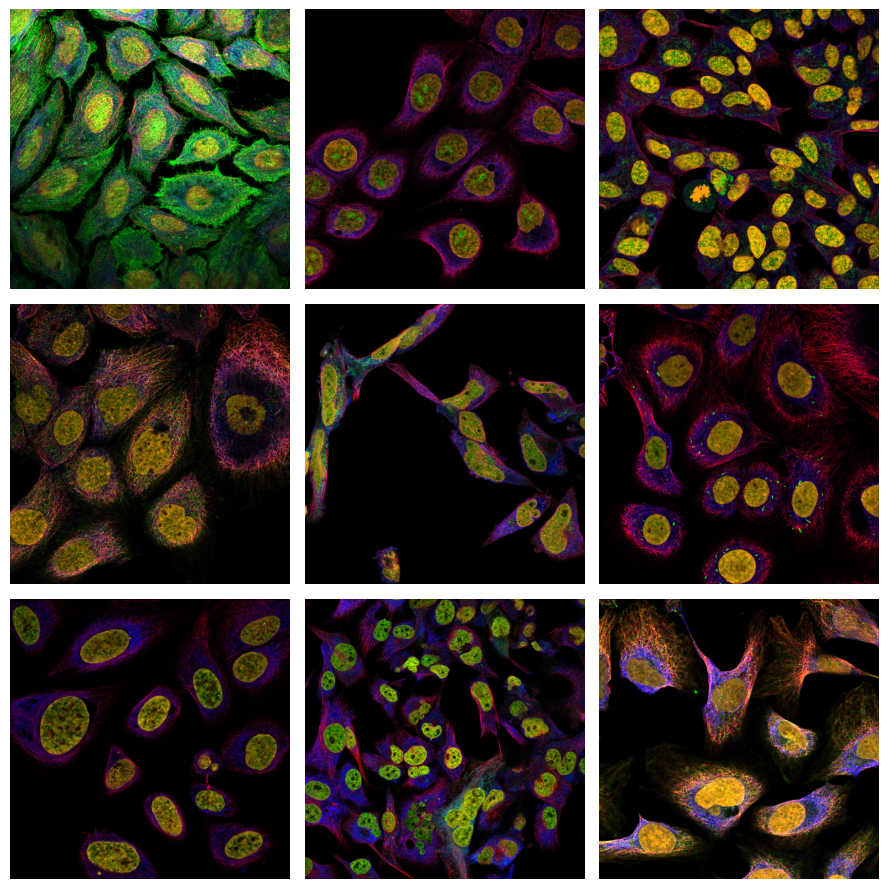

In [13]:
# Exemplo de uso (passando 9 índices do dataset)
indices = [0, 1, 2, 3, 4, 5, 6, 7, 8]  # Assume que 'train' é seu dataset
plot_9_images_with_4_channels_overlaid(train, indices)


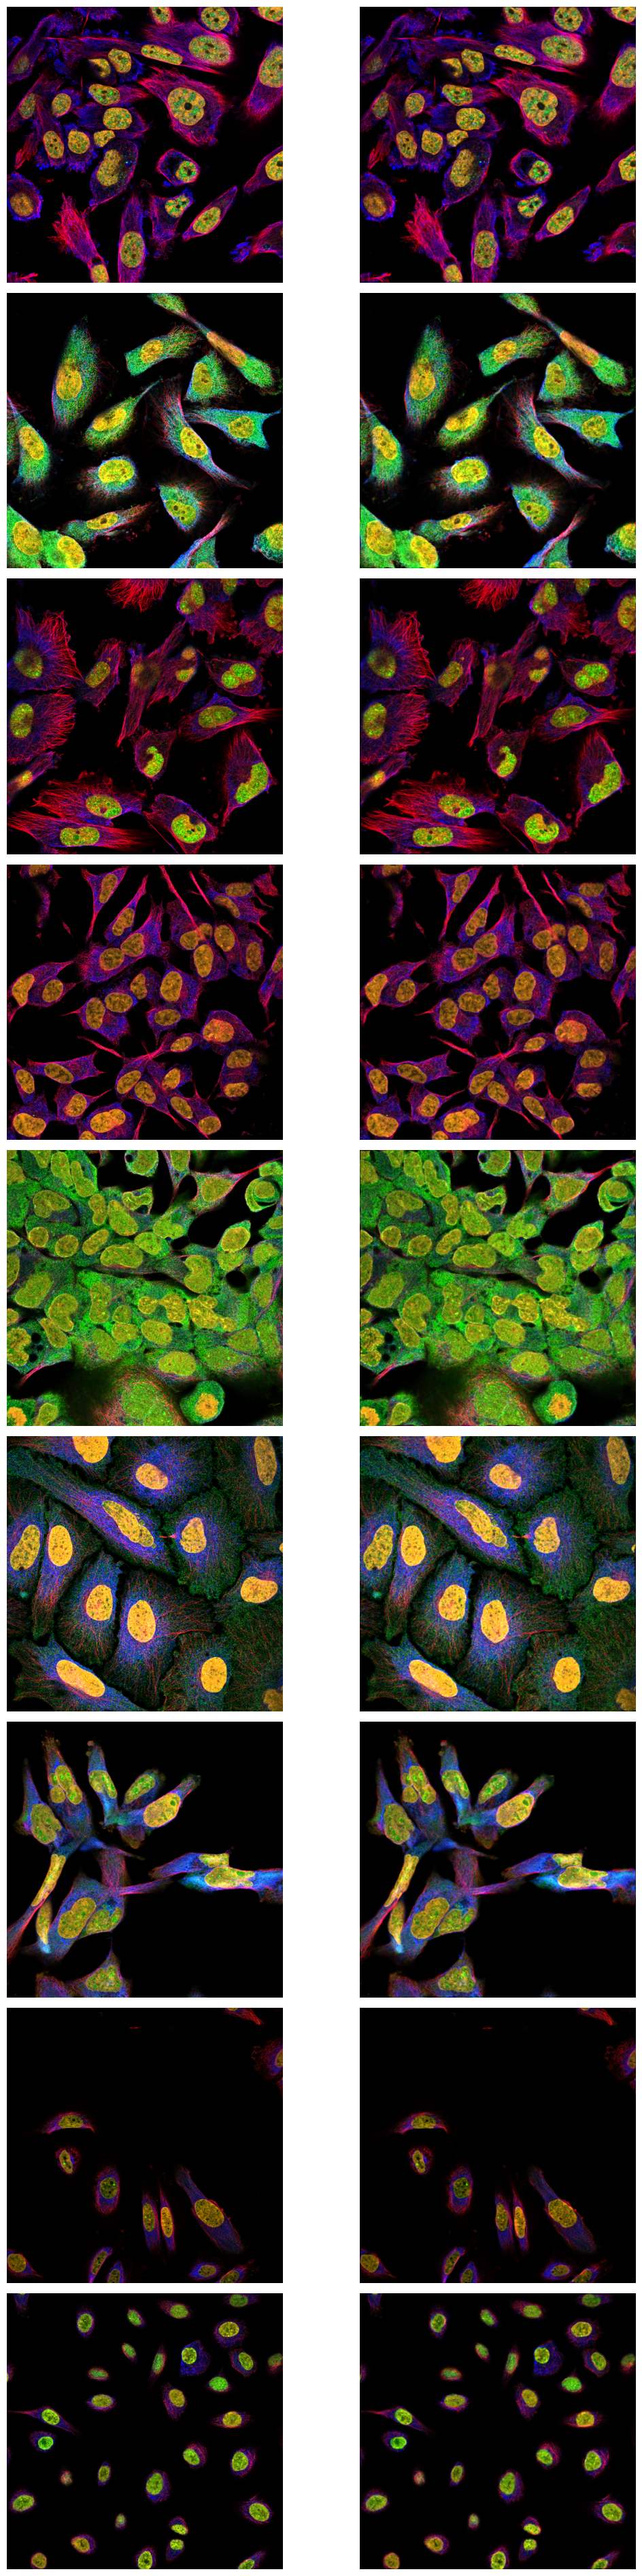

In [14]:
def plot_elastic_comparison(dataset, indices, alpha=50.0, sigma=5.0):
    """
    Plots a 3x3 grid of images comparing the original images (left) 
    and their elastic transformed versions (right).

    Args:
        dataset: The dataset containing the images.
        indices: List of 9 indices to be plotted.
        alpha: Elastic transformation intensity.
        sigma: Elastic transformation smoothness.
    """
    assert len(indices) == 9, "Provide exactly 9 indices for a 3x3 comparison."

    # Elastic transformation
    elastic_transform = transforms.ElasticTransform(alpha=alpha, sigma=sigma)

    # Define channel colors (RGBA)
    channel_colors = {
        'blue': (0, 0, 1, 0.3),
        'red': (1, 0, 0, 0.3),
        'orange': (1, 0.6, 0, 0.3),
        'green': (0, 1, 0, 0),
    }

    # Create a 3x3 grid with 2 columns (original vs transformed)
    fig, axes = plt.subplots(9, 2, figsize=(12, 38))

    for row, idx in enumerate(indices):
        # Get original image
        image = dataset.__getitem__(idx)[0]

        # Apply elastic transformation (fix: unsqueeze(0) for correct shape)
        transformed_image = torch.stack([elastic_transform(image[i].unsqueeze(0))[0] for i in range(4)])

        # Function to overlay channels into a single RGB image
        def overlay_channels(image_tensor):
            combined_image = np.zeros((image_tensor.shape[1], image_tensor.shape[2], 3), dtype=np.float32)
            for i, (_, color) in enumerate(channel_colors.items()):
                channel_image = image_tensor[i].numpy()
                channel_image = (channel_image - np.min(channel_image)) / (np.max(channel_image) - np.min(channel_image) + 1e-5)
                for j in range(3):  
                    combined_image[:, :, j] += channel_image * color[j]
            return np.clip(combined_image, 0, 1)

        # Plot original image
        axes[row, 0].imshow(overlay_channels(image))
        axes[row, 0].axis("off")
        # axes[row, 0].set_title("Original")

        # Plot transformed image
        axes[row, 1].imshow(overlay_channels(transformed_image))
        axes[row, 1].axis("off")
        # axes[row, 1].set_title("Elastic Transformed")

    plt.tight_layout()
    plt.show()

# Example: Select 9 random images to compare
indices = np.random.choice(len(train), 9, replace=False)
plot_elastic_comparison(train, indices, alpha=50.0, sigma=5.0)